# SIAP — Sistema Inteligente de Adaptación Pedagógica
### Notebook de análisis y entrenamiento del modelo

Este notebook documenta el desarrollo del modelo de SIAP siguiendo la
metodología **CRISP-DM**. SIAP recibe el perfil de un estudiante
(necesidades auditivas, visuales y ritmo de aprendizaje) y sugiere al
docente una adaptación curricular.

> **Nota:** este notebook parte de datos **sintéticos** de ejemplo.
> Sustituye la sección 2 (Comprensión de los datos) por la carga de tu
> dataset real de estudiantes cuando esté disponible, y vuelve a correr
> el resto de las celdas sin cambios en la lógica.


## 1. Comprensión del negocio

**Problema:** los docentes atienden grupos con necesidades muy diversas (auditivas, visuales, ritmo de aprendizaje lento o rápido, entre otras) y no siempre cuentan con el tiempo o las herramientas para diseñar una adaptación curricular personalizada por estudiante.

**Objetivo del modelo:** dado el perfil de un estudiante, sugerir de forma automática el tipo de adaptación curricular más adecuado, como apoyo para el docente (no como reemplazo de su criterio pedagógico).

In [1]:
# Librerías utilizadas en el proyecto
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Comprensión de los datos

Se simula un conjunto de datos de estudiantes con las siguientes variables:

| Variable | Descripción | Tipo |
|---|---|---|
| `necesidad_auditiva` | 1 si el estudiante presenta necesidad auditiva | binaria |
| `necesidad_visual` | 1 si el estudiante presenta necesidad visual | binaria |
| `ritmo_aprendizaje` | 0 = lento, 1 = normal, 2 = rápido | categórica ordinal |
| `desempeno_promedio` | promedio académico (0-100) | numérica |
| `adaptacion_sugerida` | variable objetivo (0-4) | categórica |

> Reemplaza `generar_datos_sinteticos()` por `pd.read_csv('tu_dataset.csv')` cuando tengas datos reales de estudiantes (respetando la privacidad y anonimizando cualquier dato sensible).

In [2]:
def generar_datos_sinteticos(n: int = 600, semilla: int = RANDOM_STATE) -> pd.DataFrame:
    """Genera un dataset sintético de perfiles estudiantiles para SIAP.

    Parameters
    ----------
    n : int
        Número de estudiantes a simular.
    semilla : int
        Semilla para reproducibilidad.

    Returns
    -------
    pd.DataFrame
        Dataset con variables de entrada y la etiqueta objetivo.
    """
    rng = np.random.default_rng(semilla)

    necesidad_auditiva = rng.integers(0, 2, size=n)
    necesidad_visual = rng.integers(0, 2, size=n)
    ritmo_aprendizaje = rng.integers(0, 3, size=n)
    desempeno_promedio = rng.normal(70, 15, size=n).clip(0, 100)

    etiquetas = []
    for aud, vis, ritmo in zip(necesidad_auditiva, necesidad_visual, ritmo_aprendizaje):
        if aud == 1:
            etiquetas.append(0)   # Apoyo auditivo
        elif vis == 1:
            etiquetas.append(1)   # Apoyo visual
        elif ritmo == 0:
            etiquetas.append(2)   # Refuerzo, ritmo lento
        elif ritmo == 2:
            etiquetas.append(3)   # Retos adicionales, ritmo rápido
        else:
            etiquetas.append(4)   # Sin adaptación específica

    return pd.DataFrame({
        "necesidad_auditiva": necesidad_auditiva,
        "necesidad_visual": necesidad_visual,
        "ritmo_aprendizaje": ritmo_aprendizaje,
        "desempeno_promedio": desempeno_promedio,
        "adaptacion_sugerida": etiquetas,
    })

df = generar_datos_sinteticos()
df.head()


,necesidad_auditiva,necesidad_visual,ritmo_aprendizaje,desempeno_promedio,adaptacion_sugerida
0,0,1,2,61.226888,1
1,1,1,1,69.301191,0
2,1,1,2,74.182964,0
3,0,0,2,54.881606,3
4,0,1,1,80.864240,1


In [3]:
# Exploración rápida de los datos (EDA)
print("Dimensiones:", df.shape)
print("\nDistribución de la variable objetivo:")
print(df["adaptacion_sugerida"].value_counts().sort_index())

df.describe()


Dimensiones: (600, 5)

Distribución de la variable objetivo:
adaptacion_sugerida
0    296
1    159
2     37
3     59
4     49
Name: count, dtype: int64


,necesidad_auditiva,necesidad_visual,ritmo_aprendizaje,desempeno_promedio,adaptacion_sugerida
count,600.000000,600.000000,600.000000,600.000000,600.000000
mean,0.493333,0.528333,0.998333,69.919569,1.010000
std,0.500373,0.499613,0.820235,15.012957,1.298477
min,0.000000,0.000000,0.000000,15.273808,0.000000
25%,0.000000,0.000000,0.000000,60.513170,0.000000
50%,0.000000,1.000000,1.000000,70.284124,1.000000
75%,1.000000,1.000000,2.000000,79.781835,1.000000
max,1.000000,1.000000,2.000000,100.000000,4.000000


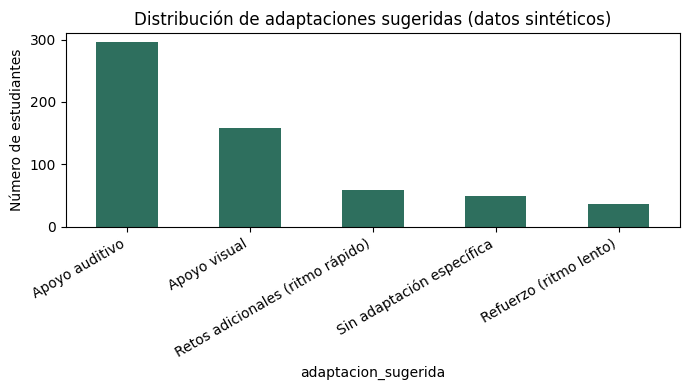

In [4]:
# Visualización de la distribución de clases
etiquetas_nombre = {
    0: "Apoyo auditivo",
    1: "Apoyo visual",
    2: "Refuerzo (ritmo lento)",
    3: "Retos adicionales (ritmo rápido)",
    4: "Sin adaptación específica",
}

conteo = df["adaptacion_sugerida"].map(etiquetas_nombre).value_counts()
conteo.plot(kind="bar", figsize=(7, 4), color="#2E6F5E")
plt.title("Distribución de adaptaciones sugeridas (datos sintéticos)")
plt.ylabel("Número de estudiantes")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 3. Preparación de los datos

Se separan variables predictoras (`X`) y variable objetivo (`y`), y se dividen los datos en entrenamiento y prueba, manteniendo la proporción de clases con `stratify`.

In [5]:
FEATURES = ["necesidad_auditiva", "necesidad_visual", "ritmo_aprendizaje", "desempeno_promedio"]
TARGET = "adaptacion_sugerida"

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

print("Entrenamiento:", X_train.shape, " Prueba:", X_test.shape)


Entrenamiento: (450, 4)  Prueba: (150, 4)


## 4. Modelado

Se entrena un `RandomForestClassifier` de scikit-learn. Este algoritmo se eligió por su buen desempeño con variables mixtas (binarias, ordinales y numéricas) y porque permite interpretar la importancia de cada variable en la sugerencia final.

In [6]:
def entrenar_modelo(X_train: pd.DataFrame, y_train: pd.Series) -> RandomForestClassifier:
    """Entrena el modelo de clasificación de SIAP.

    Parameters
    ----------
    X_train : pd.DataFrame
        Variables predictoras de entrenamiento.
    y_train : pd.Series
        Variable objetivo de entrenamiento.

    Returns
    -------
    RandomForestClassifier
        Modelo entrenado.
    """
    modelo = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
    modelo.fit(X_train, y_train)
    return modelo

modelo = entrenar_modelo(X_train, y_train)
modelo


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## 5. Evaluación

Se evalúa el modelo sobre el conjunto de prueba con `accuracy`, `classification_report` y la matriz de confusión, y se revisa la importancia de cada variable para asegurar que las sugerencias tengan sentido pedagógico (por ejemplo, que `necesidad_auditiva` sea determinante para sugerir apoyo auditivo).

In [7]:
y_pred = modelo.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(
    y_test, y_pred,
    target_names=[etiquetas_nombre[i] for i in sorted(etiquetas_nombre)]
))


Accuracy: 1.0

                                  precision    recall  f1-score   support

                  Apoyo auditivo       1.00      1.00      1.00        74
                    Apoyo visual       1.00      1.00      1.00        40
          Refuerzo (ritmo lento)       1.00      1.00      1.00         9
Retos adicionales (ritmo rápido)       1.00      1.00      1.00        15
       Sin adaptación específica       1.00      1.00      1.00        12

                        accuracy                           1.00       150
                       macro avg       1.00      1.00      1.00       150
                    weighted avg       1.00      1.00      1.00       150



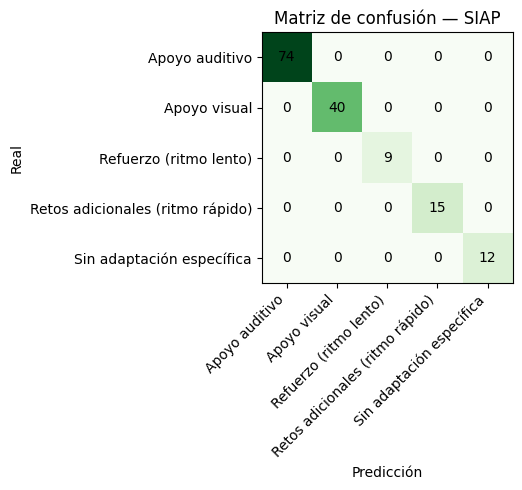

In [8]:
# Matriz de confusión
matriz = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(matriz, cmap="Greens")
ax.set_xticks(range(len(etiquetas_nombre)))
ax.set_yticks(range(len(etiquetas_nombre)))
ax.set_xticklabels(etiquetas_nombre.values(), rotation=45, ha="right")
ax.set_yticklabels(etiquetas_nombre.values())
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
ax.set_title("Matriz de confusión — SIAP")
for i in range(matriz.shape[0]):
    for j in range(matriz.shape[1]):
        ax.text(j, i, matriz[i, j], ha="center", va="center", color="black")
plt.tight_layout()
plt.show()


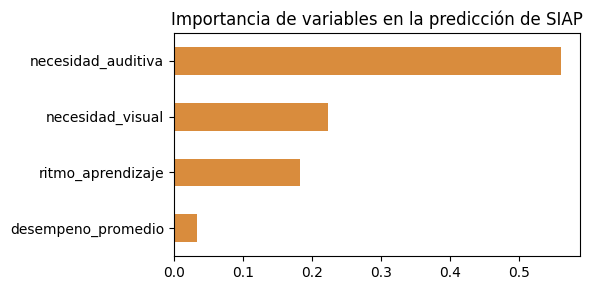

In [9]:
# Importancia de variables
importancias = pd.Series(modelo.feature_importances_, index=FEATURES).sort_values()
importancias.plot(kind="barh", figsize=(6, 3), color="#D98C3D")
plt.title("Importancia de variables en la predicción de SIAP")
plt.tight_layout()
plt.show()


## 6. Despliegue

El modelo entrenado se expone al docente mediante una aplicación en **Streamlit** (`app.py`) y el código completo del proyecto se publica en un repositorio de **GitHub**, junto con este notebook y el `README.md` con las instrucciones de instalación y ejecución.

Para llevar este modelo (en lugar del de ejemplo dentro de `app.py`) a producción:

In [10]:
import joblib

joblib.dump(modelo, "modelo_siap.pkl")
print("Modelo guardado en modelo_siap.pkl")
# En app.py: modelo = joblib.load("modelo_siap.pkl")


Modelo guardado en modelo_siap.pkl


### Conclusiones

- El modelo de ejemplo alcanza una exactitud alta sobre datos sintéticos gracias a que las reglas de generación son claras; el verdadero reto al usar datos reales será la calidad y el balance de las clases.
- Las variables `necesidad_auditiva` y `necesidad_visual` dominan la decisión cuando están presentes, lo cual es coherente con el diseño pedagógico de SIAP.
- Próximos pasos: incorporar datos reales y anonimizados de estudiantes, validar las sugerencias con docentes, y ampliar el catálogo de adaptaciones curriculares disponibles.